# EDA — Credit Risk Scoring (dados reais)

**Dataset:** *Default of Credit Card Clients* (Yeh & Lien, 2009) — UCI Machine
Learning Repository. 30.000 clientes de cartão de crédito de Taiwan, com o
histórico de pagamento de **abril a setembro de 2005** e o desfecho de
inadimplência no mês seguinte.

Objetivo desta análise: entender o que a base realmente contém — incluindo o que
**contradiz a documentação oficial** — e decidir a engenharia de features a
partir disso, não de intuição.

Rode o ETL antes: `python -m src.data.etl`

In [1]:
import sys; sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.features.build_features import add_engineered_features

plt.rcParams['figure.dpi'] = 110

df = pd.read_parquet(config.PROCESSED_PARQUET)
com_features = add_engineered_features(df)

print(f'{len(df):,} clientes  |  {df.shape[1]} colunas'.replace(',', '.'))
print(f"taxa de inadimplência: {df['default'].mean():.2%}")
df.head(3)

29.965 clientes  |  24 colunas
taxa de inadimplência: 22.13%


,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


## 1. O que a documentação promete e o que o arquivo entrega

Este é o primeiro trabalho real de qualquer base pública: conferir se os códigos
existentes batem com o dicionário de dados. Aqui, três colunas não batem.

In [2]:
bruto = pd.read_csv(config.RAW_CSV)

print('EDUCATION — documentado: 1=pós, 2=universitário, 3=médio, 4=outros')
print(bruto['education'].value_counts().sort_index().to_string())
print()
print('MARRIAGE — documentado: 1=casado, 2=solteiro, 3=outros')
print(bruto['marriage'].value_counts().sort_index().to_string())
print()
print('duplicatas exatas:', bruto.duplicated().sum())
print('faturas negativas em bill_amt1:', (bruto['bill_amt1'] < 0).sum())

EDUCATION — documentado: 1=pós, 2=universitário, 3=médio, 4=outros
education
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51

MARRIAGE — documentado: 1=casado, 2=solteiro, 3=outros
marriage
0       54
1    13659
2    15964
3      323

duplicatas exatas: 35
faturas negativas em bill_amt1: 590


`education` traz os códigos **0, 5 e 6** e `marriage` traz o **0** — nenhum
deles documentado. Somados são poucas centenas de registros, então o tratamento
adotado no ETL é colapsá-los em "outros": manter categorias com dezenas de
exemplos só produziria colunas de one-hot com ruído.

As **faturas negativas** ficam como estão: são saldo a favor do cliente, não erro.

O caso interessante é o terceiro.

## 2. `pay_*`: os códigos não documentados carregam o sinal

A documentação descreve `PAY_*` como `-1 = pago em dia` e `1..9 = meses de
atraso`. O arquivo também contém **-2** e **0**, sem explicação. A leitura
consensual é `-2 = sem consumo no mês` e `0 = crédito rotativo` (pagou o mínimo).

A tentação é tratar a coluna como um número ordinal — quanto maior, pior. Os
dados dizem outra coisa.

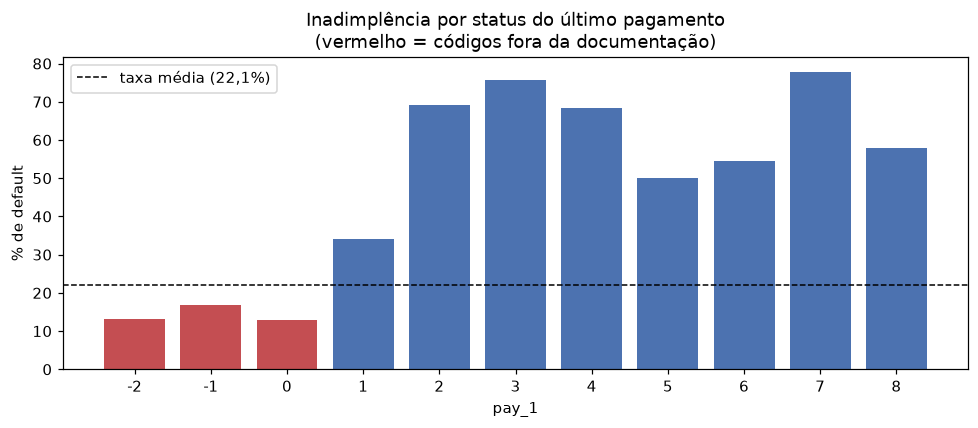

,clientes,taxa
pay_1,,
-2,2750,13.2
-1,5682,16.8
0,14737,12.8
1,3667,34.0
2,2666,69.1
3,322,75.8
4,76,68.4
5,26,50.0
6,11,54.5


In [3]:
por_status = df.groupby('pay_1')['default'].agg(clientes='size', taxa='mean')
por_status['taxa'] = (por_status['taxa'] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
cores = ['#c44e52' if i in (-2, -1, 0) else '#4c72b0' for i in por_status.index]
ax.bar(por_status.index.astype(str), por_status['taxa'], color=cores)
ax.axhline(df['default'].mean() * 100, ls='--', c='k', lw=1, label='taxa média (22,1%)')
ax.set_title('Inadimplência por status do último pagamento\n(vermelho = códigos fora da documentação)')
ax.set_xlabel('pay_1'); ax.set_ylabel('% de default'); ax.legend()
plt.tight_layout(); plt.show()

por_status

**A relação não é monótona.** Entre os três códigos não documentados:

| Código | Leitura | Clientes | Default |
|---|---|---:|---:|
| `-2` | sem consumo | 2.750 | 13,2% |
| `-1` | pagou a fatura inteira | 5.682 | **16,8%** |
| `0` | crédito rotativo (pagou o mínimo) | 14.737 | **12,8%** |

Quem **quita a fatura toda** inadimple **mais** do que quem rola a dívida no
rotativo. É contraintuitivo e é real — provavelmente porque o grupo `-1` mistura
bons pagadores com quem tem fatura baixíssima e conta pouco ativa.

A partir do código `1` a escala volta a fazer sentido e sobe forte: 34% com um
mês de atraso, **69% com dois**.

**Consequência direta:** alimentar `pay_1` como um inteiro numa escala linear diz
ao modelo que -2 < -1 < 0 em risco, o que é **falso**. Por isso a feature
engineering conta *regimes* em vez de usar o número cru.

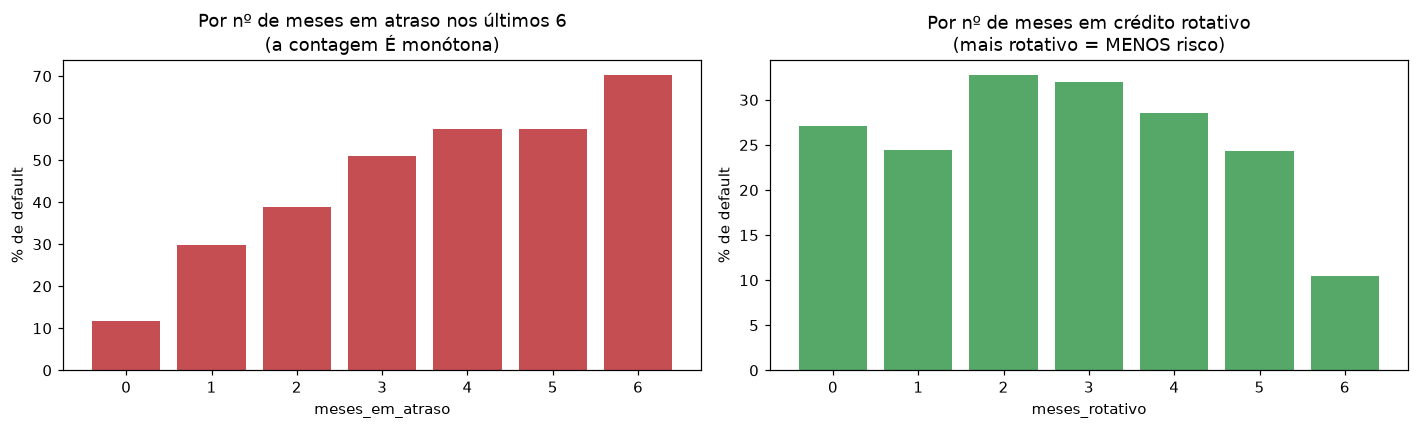

,clientes,taxa
meses_em_atraso,,
0,19918,11.7
1,4405,29.9
2,1899,38.8
3,1154,50.9
4,951,57.3
5,298,57.4
6,1340,70.3


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

por_atraso = com_features.groupby('meses_em_atraso')['default'].agg(clientes='size', taxa='mean')
por_atraso['taxa'] = (por_atraso['taxa'] * 100).round(1)
ax[0].bar(por_atraso.index.astype(str), por_atraso['taxa'], color='#c44e52')
ax[0].set_title('Por nº de meses em atraso nos últimos 6\n(a contagem É monótona)')
ax[0].set_xlabel('meses_em_atraso'); ax[0].set_ylabel('% de default')

por_rotativo = com_features.groupby('meses_rotativo')['default'].mean() * 100
ax[1].bar(por_rotativo.index.astype(str), por_rotativo.values, color='#55a868')
ax[1].set_title('Por nº de meses em crédito rotativo\n(mais rotativo = MENOS risco)')
ax[1].set_xlabel('meses_rotativo'); ax[1].set_ylabel('% de default')

plt.tight_layout(); plt.show()
por_atraso

Separando os regimes, cada um vira uma variável bem-comportada:
`meses_em_atraso` cresce de **11,7%** (nenhum atraso) a **70,3%** (seis meses),
enquanto `meses_rotativo` anda na direção oposta. Duas features monótonas no
lugar de uma coluna que não era ordinal.

## 3. Utilização do limite

O driver clássico de risco em cartão. Aqui ele também não é uma reta.

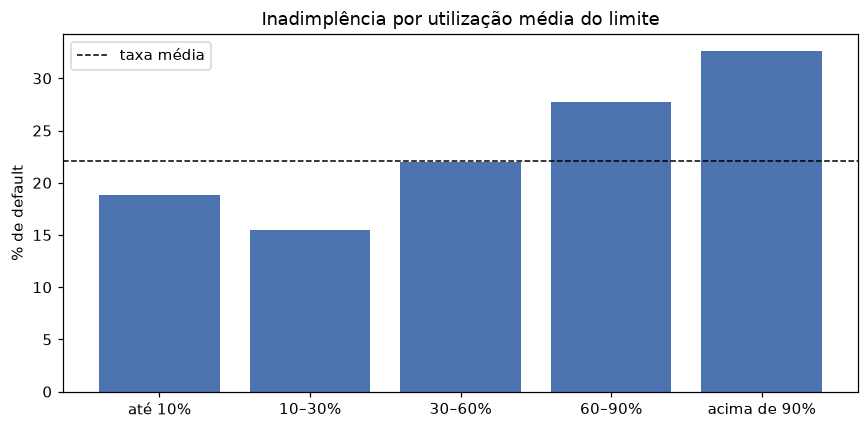

,clientes,taxa
utilization_mean,,
até 10%,11011,18.8
10–30%,4221,15.5
30–60%,5470,22.0
60–90%,6461,27.7
acima de 90%,2802,32.6


In [5]:
faixas = pd.cut(com_features['utilization_mean'],
                bins=[-float('inf'), 0.1, 0.3, 0.6, 0.9, float('inf')],
                labels=['até 10%', '10–30%', '30–60%', '60–90%', 'acima de 90%'])
por_uso = com_features.groupby(faixas, observed=True)['default'].agg(clientes='size', taxa='mean')
por_uso['taxa'] = (por_uso['taxa'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(por_uso.index.astype(str), por_uso['taxa'], color='#4c72b0')
ax.axhline(df['default'].mean() * 100, ls='--', c='k', lw=1, label='taxa média')
ax.set_title('Inadimplência por utilização média do limite')
ax.set_xlabel(''); ax.set_ylabel('% de default'); ax.legend()
plt.tight_layout(); plt.show()

por_uso

De 10% para cima o comportamento é o esperado: quanto mais do limite
comprometido, maior o risco (15,5% → 32,6%). Mas a faixa **até 10% quebra o
padrão**, com 18,8% — mais arriscada que a faixa seguinte.

São majoritariamente contas **pouco ativas**, o mesmo fenômeno visto no código
`-2` de `pay_*`: pouca informação de comportamento, e não bom comportamento. O
modelo precisa das duas variáveis (utilização e regime de pagamento) para separar
"cliente saudável que usa pouco" de "conta parada".

## 4. Correlação das features derivadas com o alvo

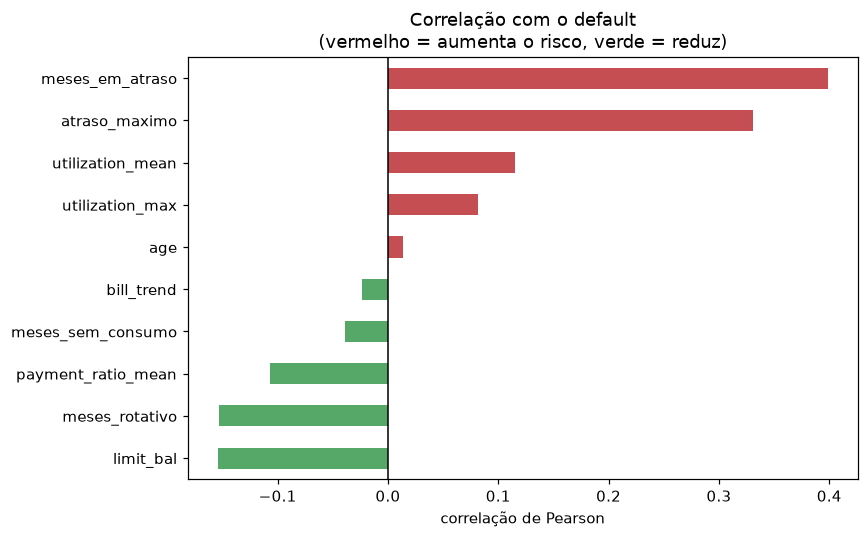

meses_em_atraso       0.398
atraso_maximo         0.331
utilization_mean      0.115
utilization_max       0.082
age                   0.014
bill_trend           -0.024
meses_sem_consumo    -0.039
payment_ratio_mean   -0.107
meses_rotativo       -0.154
limit_bal            -0.154
Name: default, dtype: float64

In [6]:
derivadas = ['meses_em_atraso', 'atraso_maximo', 'utilization_mean', 'utilization_max',
             'payment_ratio_mean', 'meses_rotativo', 'meses_sem_consumo',
             'bill_trend', 'limit_bal', 'age']
corr = com_features[derivadas + ['default']].corr()['default'].drop('default').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
cores = ['#55a868' if v < 0 else '#c44e52' for v in corr]
corr.plot(kind='barh', ax=ax, color=cores)
ax.axvline(0, c='k', lw=1)
ax.set_title('Correlação com o default\n(vermelho = aumenta o risco, verde = reduz)')
ax.set_xlabel('correlação de Pearson')
plt.tight_layout(); plt.show()

corr.sort_values(ascending=False).round(3)

## Conclusões para a modelagem

**1. Comportamento de pagamento domina, cadastro quase não importa.**
`meses_em_atraso` (0,398) e `atraso_maximo` (0,331) lideram com folga. `age`
fica em 0,014 — praticamente nada. Um modelo de risco aqui é um modelo de
*comportamento recente*, não de perfil demográfico.

**2. As features derivadas superam as colunas cruas.** `meses_em_atraso` é uma
contagem construída a partir de seis colunas que, isoladas, não são ordinais.
Essa é a contribuição real da feature engineering neste projeto.

**3. Duas variáveis protetoras, ambas contraintuitivas:** `meses_rotativo`
(−0,154) e `limit_bal` (−0,154). Limite alto reduz risco porque é *consequência*
de um bom histórico — o banco já concedeu confiança a esse cliente. É uma
variável endógena, e vale registrar isso: num sistema em produção, usar o limite
para decidir crédito realimenta a própria política que o gerou.

**4. A base é desbalanceada (22,1%),** o que sustenta SMOTE apenas no treino e o
uso de PR-AUC/KS em vez de acurácia — aprovar todos já "acerta" 77,9%.

**5. Esta base é genuinamente difícil.** O ROC-AUC obtido (0,773) está alinhado
com a literatura publicada para este dataset, e bem abaixo dos números que uma
base sintética produz. O teto é do problema, não do pipeline.